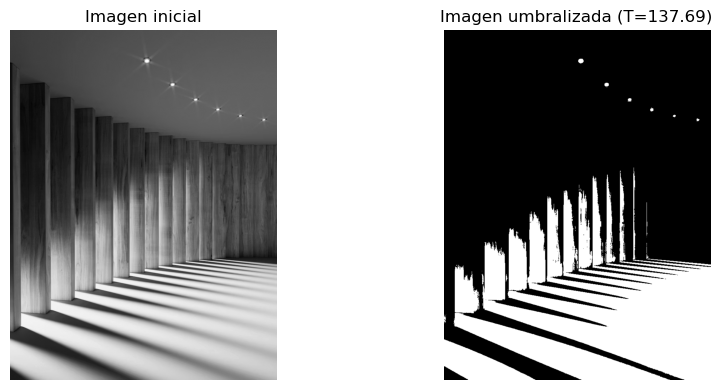

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def isodata(image):
    umbral = 128
    while True:
        grupo1 = image[image <= umbral]  # grupo donde el umbral es menor o igual
        grupo2 = image[image > umbral]   # grupo donde el umbral es mayor

        media1 = np.mean(grupo1) if grupo1.size > 0 else 0
        media2 = np.mean(grupo2) if grupo2.size > 0 else 0

        nuevo_umbral = (media1 + media2) / 2  # nuevo umbral promedio de medias

        if abs(umbral - nuevo_umbral) < 0.5:
            break
        umbral = nuevo_umbral
    return umbral

imagen = cv2.imread('fondo.jpeg', 0)
if imagen is None:
    raise FileNotFoundError('No hay imagen papito')

umbral_isodata = isodata(imagen)
_, imagen_umbralizada = cv2.threshold(imagen, umbral_isodata, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(imagen, cmap='gray')
plt.title('Imagen inicial')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(imagen_umbralizada, cmap='gray')
plt.title(f'Imagen umbralizada (T={umbral_isodata:.2f})')
plt.axis('off')

plt.tight_layout()
plt.show()

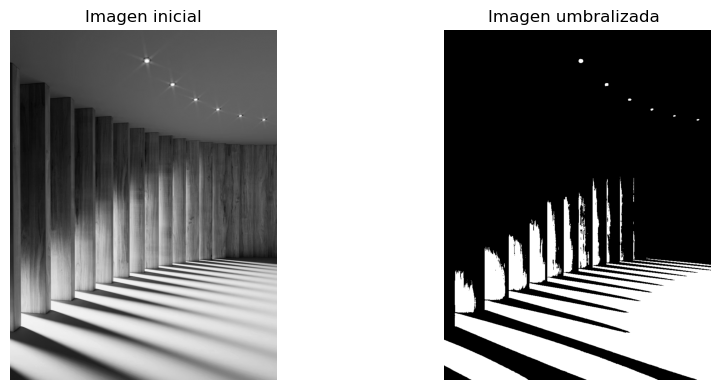

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def dos_picos(image):
    hist = cv2.calcHist([image], [0], None, [256], [0, 256]) #hago uso de histograma
    #seleccionamos los 2 picos 
    pico=np.array(hist)
    pico=pico.flatten()
    pico_dif=np.diff(pico) #diferencia entre los tipos
    primer_pico=np.argmax(pico_dif[:128]) #primer pico
    segundo_pico=np.argmax(pico_dif[128:])+128 #segundo pico

    umbral= int((primer_pico + segundo_pico) / 2) #umbral entre los 2 picos
    return umbral

imagen=cv2.imread('fondo.jpeg', 0)
umbral_2_picos=dos_picos(imagen)

_, nueva = cv2.threshold(imagen, umbral_2_picos, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(imagen, cmap='gray')
plt.title('Imagen inicial')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(nueva, cmap='gray')
plt.title(f'Imagen umbralizada ')
plt.axis('off')

plt.tight_layout()
plt.show()

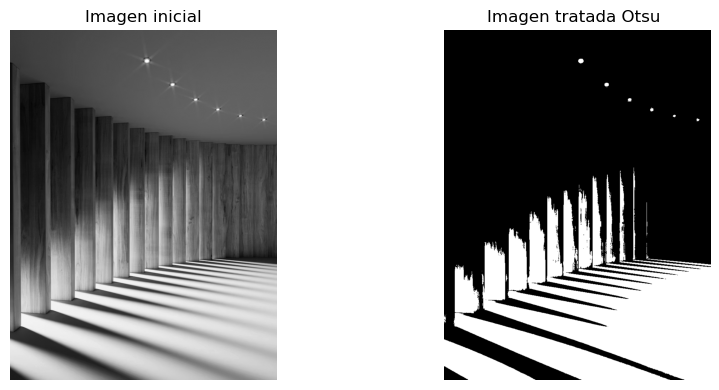

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('fondo.jpeg', 0)
umbral_otsu, otsu = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
imagen_fin = np.where(image > umbral_otsu, 255, 0).astype(np.uint8)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Imagen inicial')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(imagen_fin, cmap='gray')
plt.title(f'Imagen tratada Otsu ')
plt.axis('off')

plt.tight_layout()
plt.show()

UMBRALIZACIÓN VARIABLE PARTICION DE UNA IMAGEN

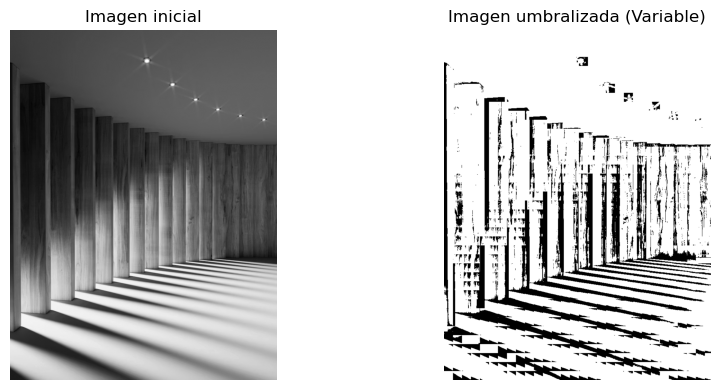

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
def variable_part(image,tam_bloque,c):
    umbral_img=np.zeros_like(image)
    for y in range(0,image.shape[0],tam_bloque):
        for x in range(0,image.shape[1],tam_bloque):
            bloque=image[y:y+tam_bloque,x:x+tam_bloque]
            bloq_media=np.mean(bloque)
            umbral=bloq_media-c
            umbral_img[y:y+tam_bloque,x:x+tam_bloque]=(bloque>umbral)*255
    return umbral_img
tam_b=25
c=10
imagen=cv2.imread('fondo.jpeg', 0)
img_fin=variable_part(imagen, tam_b, c)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(imagen, cmap='gray')
plt.title('Imagen inicial')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(img_fin, cmap='gray')
plt.title('Imagen umbralizada (Variable)')
plt.axis('off')
plt.tight_layout()
plt.show()



propiedades locales

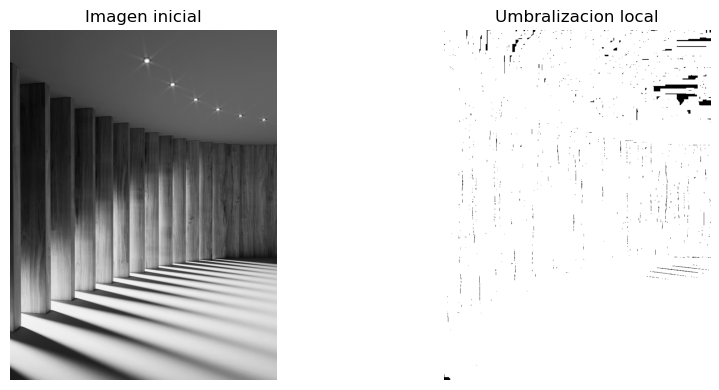

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('fondo.jpeg', 0)
def local(image, tamanio_ventana, k):
    umbr_img=np.zeros_like(image)
    pad= tamanio_ventana//2
    padded_image = cv2.copyMakeBorder(image, pad, pad, pad, pad, cv2.BORDER_REPLICATE)
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            ventana = padded_image[y:y+tamanio_ventana, x:x+tamanio_ventana]
            mean_local=np.mean(ventana)
            std_mean=np.std(ventana)

            umbral=mean_local-(k*std_mean)
            umbr_img[y,x]=255 if image[y,x]>umbral else 0
    return umbr_img
tamanio_ventana=15
k=2
img_fin=local(image, tamanio_ventana, k)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Imagen inicial')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_fin, cmap='gray')
plt.title('Umbralizacion local')
plt.axis('off')

plt.tight_layout()
plt.show()

variable con open cv

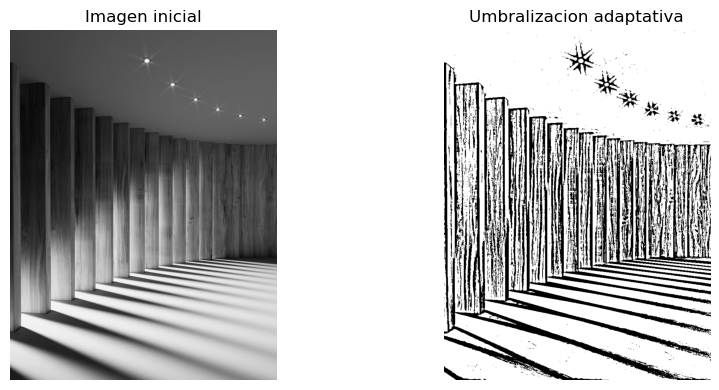

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('fondo.jpeg', 0)

ventana = 15
k = 2
imagen_fin = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, ventana, k)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Imagen inicial')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(imagen_fin, cmap='gray')
plt.title('Umbralizacion adaptativa')
plt.axis('off')

plt.tight_layout()
plt.show()

137
3217.6446
137 137 0


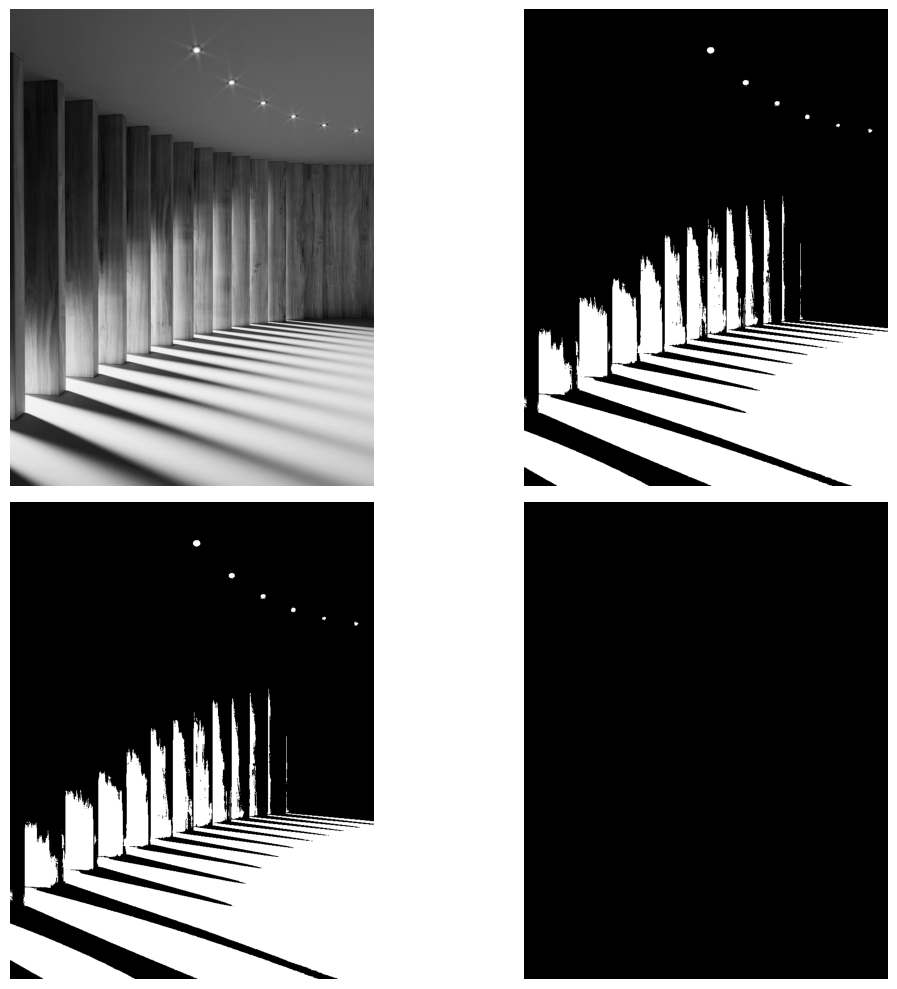

In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def otsu_desde_cero(imagen):
    imagen_norm = imagen.astype(np.float32) / 255.0
    hist, bin_edges = np.histogram(imagen_norm, bins=256, range=(0, 1))
    hist = hist / np.sum(hist)

    x = np.arange(256)
    varianzas = np.zeros(256)

    for t in range(256):
        w0 = np.sum(hist[:t+1])
        w1 = 1.0 - w0

        if w0 == 0 or w1 == 0:
            continue

        mu0 = np.sum(x[:t+1] * hist[:t+1]) / w0
        mu1 = np.sum(x[t+1:] * hist[t+1:]) / w1

        varianza_entre = w0 * w1 * (mu0 - mu1) ** 2
        varianzas[t] = varianza_entre

    umbral_optimo = np.argmax(varianzas)
    return umbral_optimo, varianzas


imagen = cv2.imread('fondo.jpeg', 0)
umbral_otsu_manual, varianzas = otsu_desde_cero(imagen)

umbral_otsu_cv, imagen_otsu_cv = cv2.threshold(
    imagen, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

_, imagen_otsu_manual = cv2.threshold(
    imagen, umbral_otsu_manual, 255, cv2.THRESH_BINARY
)

print(umbral_otsu_manual)
print(f"{varianzas[umbral_otsu_manual]:.4f}")
print(umbral_otsu_manual, int(umbral_otsu_cv),
      abs(umbral_otsu_manual - int(umbral_otsu_cv)))

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(imagen, cmap='gray')
axes[0, 0].axis('off')

axes[0, 1].imshow(imagen_otsu_manual, cmap='gray')
axes[0, 1].axis('off')

axes[1, 0].imshow(imagen_otsu_cv, cmap='gray')
axes[1, 0].axis('off')

diferencia = cv2.absdiff(imagen_otsu_manual, imagen_otsu_cv)
axes[1, 1].imshow(diferencia, cmap='gray')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()
